# Behaviour of the spacing test when the two maxima are close

This notebook studies two questions about the spacing test: *what happens to the
power when the maximum and the second maximum are very close*, and *how should the
p-value be evaluated in floating-point arithmetic?*

Findings, in short:

1. The p-value goes to 1 smoothly as the spacing $\lambda_1-\lambda_2$ goes to 0. The
   test does not reject on near ties, and the level is never affected.
2. Near ties are the numerically **easy** case: the two integrals in the ratio are
   close and the ratio is close to 1.
3. The delicate case is the **far tail**: in double precision, the direct evaluation of
   $G$ loses the survival-function term for $\ell \gtrsim 8$ and returns $0/0$ for
   $\ell \gtrsim 39$. The fix is the log-scale evaluation of `tenspace/pivot.py`,
   based on the scaled complementary error function (Section 5.2 of the paper).
4. Lemma 3 of the paper implies $\lambda_2 \geq \lambda_{\max}(\Omega)$ for the true
   second maximum. This inequality is a practical check of the gradient descents.

The heavy reanalysis of the 2.79 million Monte-Carlo draws is in
`../experiments/reanalysis_spacing_power.py`; the sweeps and the fresh Monte-Carlo
runs are in `../experiments/stability_experiment.py`. This notebook uses their
committed outputs.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

sys.path.insert(0, os.path.abspath(".."))
from tenspace.pivot import (g_naive, log_g_stable, spacing_pvalue,
                                   tspacing_pvalue, is_valid_second_max)

sb.set_theme(context="paper", style="darkgrid", rc={"figure.dpi": 120})

## The pivot, evaluated two ways

`spacing_pvalue(..., method="naive")` is the direct evaluation of
$G(\lambda_1)/G(\lambda_2)$; `method="stable"` evaluates
$\exp(\log G(\lambda_1)-\log G(\lambda_2))$ on the log scale. In the moderate range
the two agree to machine precision. In the far tail the direct evaluation fails while
the log-scale evaluation returns the exact value.

In [2]:
det_r, trace_r = -0.182, -1.056  # medians of the null Monte-Carlo experiments

print("moderate range, lambda = (3.0, 1.5):")
print("  direct   :", spacing_pvalue(3.0, 1.5, det_r, trace_r, method="naive"))
print("  log-scale:", spacing_pvalue(3.0, 1.5, det_r, trace_r, method="stable"))

print("far tail, lambda = (50, 49):")
with np.errstate(all="ignore"):
    print("  direct   :", spacing_pvalue(50.0, 49.0, det_r, trace_r, method="naive"))
print("  log-scale:", spacing_pvalue(50.0, 49.0, det_r, trace_r, method="stable"))

print("Lemma-3 check on a valid draw   :", bool(is_valid_second_max(3.0, 1.5, det_r, trace_r)))
print("Lemma-3 check on an invalid draw:", bool(is_valid_second_max(4.97, 1.93, 0.09, 3.06)))
# the invalid example is an actual flagged draw of the fresh Monte-Carlo below

moderate range, lambda = (3.0, 1.5):
  direct   : 0.049468571362372635
  log-scale: 0.049468571362372635
far tail, lambda = (50, 49):
  direct   : nan
  log-scale: 3.2434568178023016e-22
Lemma-3 check on a valid draw   : True
Lemma-3 check on an invalid draw: False


## Near ties: the easy case

Spacing $\varepsilon = \lambda_1-\lambda_2$ from $1$ down to $10^{-15}$ at fixed
$(\lambda_2, \Omega)$. The p-value rises smoothly to 1; the direct (circles) and the
log-scale (lines) evaluations agree to about $10^{-14}$.

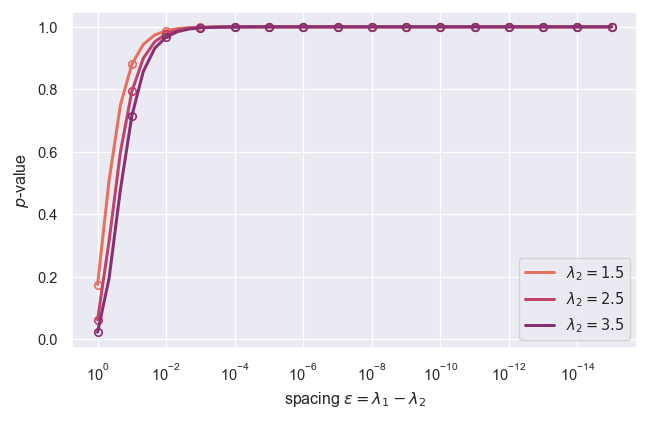

max |direct - log-scale| over the sweep: 1.4099832412739488e-14


In [3]:
near = pd.read_csv("../experiments/outputs/near_tie_sweep.csv")
colors = sb.color_palette("flare", 3)
fig, ax = plt.subplots(figsize=(5.5, 3.6))
for c, (l2, sub) in zip(colors, near.groupby("lambda_2")):
    sub = sub.sort_values("eps")
    ax.plot(sub.eps, sub.p_stable, color=c, lw=1.8, label=rf"$\lambda_2={l2}$")
    ax.plot(sub.eps[::3], sub.p_naive[::3], "o", color=c, ms=4.5, mfc="none")
ax.set_xscale("log"); ax.invert_xaxis()
ax.set(xlabel=r"spacing $\varepsilon=\lambda_1-\lambda_2$", ylabel=r"$p$-value")
ax.legend(); plt.tight_layout(); plt.show()
print("max |direct - log-scale| over the sweep:",
      float(np.abs(near.p_naive - near.p_stable).max()))

## Far tail: the delicate case

$\lambda_1$ from 2 to 60 with the spacing fixed at 1. The direct evaluation (circles)
returns NaN beyond $\lambda_1 \approx 39$ (shaded area); the log-scale evaluation
(line) follows the exact value.

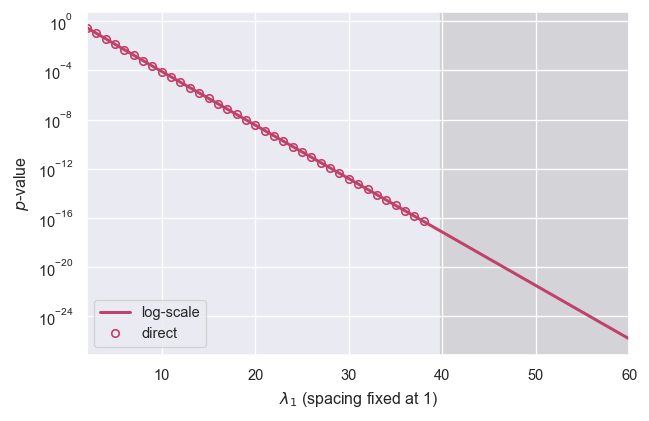

direct evaluation returns NaN from lambda_1 = 39.75


In [4]:
far = pd.read_csv("../experiments/outputs/far_tail_sweep.csv").sort_values("lambda_1")
first_nan = far[far.p_naive.isna()].lambda_1.min()
fig, ax = plt.subplots(figsize=(5.5, 3.6))
ax.plot(far.lambda_1, far.p_stable, color=colors[1], lw=1.8, label="log-scale")
ok = far.p_naive > 0
ax.plot(far.lambda_1[ok][::4], far.p_naive[ok][::4], "o", color=colors[1],
        ms=4.5, mfc="none", label="direct")
ax.axvspan(first_nan, 60, color="0.75", alpha=0.5, zorder=0)
ax.set_yscale("log")
ax.set(xlabel=r"$\lambda_1$ (spacing fixed at 1)", ylabel=r"$p$-value", xlim=(2, 60))
ax.legend(); plt.tight_layout(); plt.show()
print("direct evaluation returns NaN from lambda_1 =", float(first_nan))

## Fresh Monte-Carlo runs

2000 new replications of the 3-way, 3-dimensional spiked tensor model at $\gamma=0$
(the null) and $\gamma=2.5$, with the p-values computed by both methods on each draw
(`../experiments/stability_experiment.py`).

In [5]:
for g in ("0.0", "2.5"):
    df = pd.read_csv(f"../experiments/outputs/fresh_mc_gamma_{g}.csv")
    ok = df.p_spacing_stable.between(0, 1)
    agree = np.abs(df.p_spacing_naive - df.p_spacing_stable)[ok].max()
    print(f"gamma={g}: n={len(df)}, rejection at 5% (spacing) ="
          f" {(df.p_spacing_stable[ok] <= 0.05).mean():.4f},"
          f" (t-spacing) = {(df.p_tspacing_stable[ok] <= 0.05).mean():.4f},"
          f" max |direct - log-scale| = {agree:.2e}")
    near_ties = df[df.spacing < 0.05]
    if len(near_ties):
        print(f"  {len(near_ties)} near ties (spacing < 0.05);"
              f" smallest p-value among them: {near_ties.p_spacing_stable.min():.4f}")
    flagged = df[~df.p_spacing_stable.between(0, 1)]
    if len(flagged):
        print(f"  {len(flagged)} draws flagged (p outside [0,1]); Lemma-3 check:")
        cols = ["lambda_1", "lambda_2", "det_R", "trace_R", "p_spacing_naive"]
        print(flagged[cols].round(3).to_string())
        v = is_valid_second_max(flagged.lambda_1.values, flagged.lambda_2.values,
                                flagged.det_R.values, flagged.trace_R.values)
        print("  is_valid_second_max on the flagged draws:", v)

gamma=0.0: n=2000, rejection at 5% (spacing) = 0.0470, (t-spacing) = 0.0535, max |direct - log-scale| = 1.57e-14
  109 near ties (spacing < 0.05); smallest p-value among them: 0.9007
gamma=2.5: n=2000, rejection at 5% (spacing) = 0.9464, (t-spacing) = 0.6316, max |direct - log-scale| = 1.80e-12
  2 draws flagged (p outside [0,1]); Lemma-3 check:
      lambda_1  lambda_2  det_R  trace_R  p_spacing_naive
1120     3.867     2.662  3.985    4.627           -0.031
1273     4.974     1.931  0.090    3.056           -0.000
  is_valid_second_max on the flagged draws: [False False]


The flagged draws at $\gamma=2.5$ are gradient-descent failures (the descent
stopped below the true second maximum, so $\lambda_2 < \lambda_{\max}(\Omega)$, which
Lemma 3 excludes). They are detected both by the check $p \in [0,1]$ and by
`is_valid_second_max`.

## p-value against the observed spacing (original experiments)

A subsample of the original Monte-Carlo experiments (about 250,000 replications per
value of $\gamma$). The p-value goes to 1 as the spacing goes to 0; no rejection at
level 5% occurs below a spacing of 0.6, and 97% of the rejections have a spacing
larger than 1.5. The subsample file is produced by
`../experiments/reanalysis_spacing_power.py`.

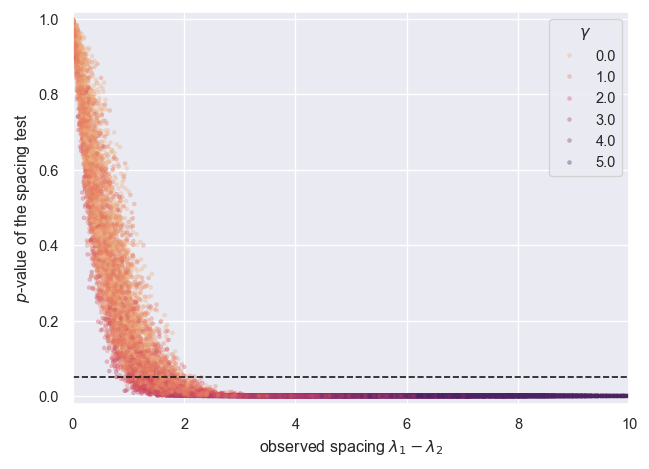

In [6]:
sample_file = "../experiments/outputs/pooled_spacing_sample.csv.gz"
if os.path.exists(sample_file):
    d = pd.read_csv(sample_file)
    d = d[d.alpha.isin([0, 1, 2, 3, 4, 5])].groupby("alpha").head(3000)
    d = d.rename(columns={"alpha": r"$\gamma$"})
    fig, ax = plt.subplots(figsize=(5.5, 4))
    sb.scatterplot(ax=ax, data=d, x="spacing", y="spacing_pvalue",
                   hue=r"$\gamma$", palette="flare", s=6, alpha=0.35,
                   edgecolor=None, rasterized=True)
    ax.axhline(0.05, color="k", linestyle="--", lw=1)
    ax.set(xlabel=r"observed spacing $\lambda_1-\lambda_2$",
           ylabel=r"$p$-value of the spacing test", xlim=(0, 10), ylim=(-0.02, 1.02))
    plt.tight_layout(); plt.show()
else:
    print("run  python3 experiments/reanalysis_spacing_power.py  first to produce", sample_file)

## Pointers

- `../tenspace/pivot.py`: the log-scale pivot and the Lemma-3 check (Section 5.2 of
  the paper).
- `../experiments/reanalysis_spacing_power.py`: reanalysis of the 2.79 million draws
  (level, power by spacing, re-evaluation of every p-value).
- `../experiments/stability_experiment.py`: the sweeps and the fresh Monte-Carlo above.
- `../experiments/make_figures.py`: the three panels of the figure of the paper
  (Section 5.2, "Behaviour when the two maxima are close").